- [ViT Paper](https://arxiv.org/pdf/2010.11929)

In [2]:
import mlflow

mlflow.set_tracking_uri("http://localhost:5000/")
mlflow.set_experiment("vit-mnist")

/home/eilliar/Repositories/computer_vision/.venv/lib/python3.13/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
2026/03/01 11:13:16 INFO mlflow.tracking.fluent: Experiment with name 'vit-mnist' does not exist. Creating a new experiment.


<Experiment: artifact_location='mlflow-artifacts:/1', creation_time=1772374396526, experiment_id='1', last_update_time=1772374396526, lifecycle_stage='active', name='vit-mnist', tags={}, workspace='default'>

# 1. Patch Embedding Layer

Idea: Split image into fixed-size patches and linearly embed them. Treat image as a sequence.

- Input: Image (e.g., 224x224x3)
- Output: Sequence of patch embeddings (e.g. 196 patches of dim 768)


Trick: Use Conv2D with kernel_size=patch_size, stride=patch_size
- This automatically extracts non-overlapping patches


In [1]:
import torch
import torch.nn as nn
import torch.optim as optim

import torchvision.datasets as datasets
import torchvision.transforms as transforms
from torch.utils.data import DataLoader

import matplotlib.pyplot as plt


In [3]:
class PatchEmbed(nn.Module):
    def __init__(self, img_size: int, patch_size: int, in_channels: int, embed_dim: int, *args, **kwargs):
        super().__init__(*args,  **kwargs)
        self.num_patches = (img_size // patch_size) ** 2

        self.projection = nn.Conv2d(
            in_channels=in_channels,
            out_channels=embed_dim,
            kernel_size=patch_size,
            stride=patch_size
        )

    def forward(self, x):
        # x shape: (batch size, channels, height, width)

        x = self.projection(x)
        # After conv (self.projection): (batch size, embed dim, num_patches_h, num_patches_w)
        x = torch.flatten(x, start_dim=2)
        # After flatten: (batch size, embed dim, num_patches)
        x = torch.transpose(x, dim0=1, dim1=2)
        # After transpose: (batch size, num_patches, embed dim)

        return x

In [4]:
batch_size = 1
img_size = 32
channels = 1

random_batch = torch.rand(batch_size, channels, img_size, img_size)
random_batch.shape

torch.Size([1, 1, 32, 32])

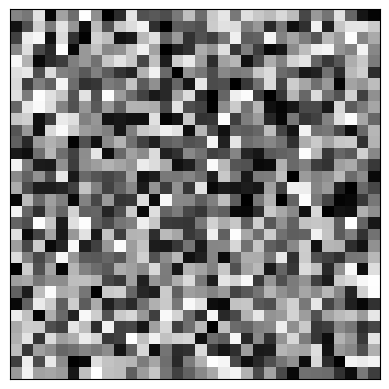

In [5]:
plt.figure()

plt.imshow(random_batch.squeeze().T, cmap=plt.cm.binary)
plt.xticks([])
plt.yticks([])
plt.grid(False)

Note that `img_size` (image dimension, in this case `Width = Height`) must be divisble by `patch_size`.

In [6]:
embed_dim = 768
patch_size = 8
assert (img_size % patch_size) == 0

In [7]:
patch_embedded = PatchEmbed(img_size=img_size, patch_size=patch_size, in_channels=channels,
                            embed_dim=embed_dim).forward(x=random_batch)
patch_embedded.shape

torch.Size([1, 16, 768])

Each patch (X pixels) -> 768-dimensional embedding

# 2. Single Head Attention

1. Query (Q): what am I looking for?
2. Key (K): What do I contain?
3. Value (V): what information do I have?

$$Attention(Q, K, V) = \text{softmax}(\frac{QK^T}{\sqrt{d_k}})V$$

In [8]:
class Attention(nn.Module):
    def __init__(self, embed_dim: int, head_dim: int, bias: bool = False, dropout_p: float = 0.0, *args, **kwargs):
        # embed_dim: input dimension
        # head_dim: dimension per head (e.g., 64)
        super().__init__(*args, **kwargs)
        self.head_dim = head_dim
        self.scale = torch.sqrt(torch.tensor(head_dim))

        # Three linear projections
        self.query = nn.Linear(in_features=embed_dim,
                               out_features=head_dim, bias=bias)
        self.key = nn.Linear(in_features=embed_dim,
                             out_features=head_dim, bias=bias)
        self.value = nn.Linear(in_features=embed_dim,
                               out_features=head_dim, bias=bias)

        self.attn_dropout = nn.Dropout(p=dropout_p)

    def forward(self, x):
        # x shape: (batch size, seq len, embed_dim)
        # seq len => n patches + 1 CLS token
        Q = self.query(x)  # (batch size, seq len, head dim)
        K = self.key(x)  # (batch size, seq len, head dim)
        V = self.value(x)  # (batch size, seq len, head dim)

        # Attention Scores
        # Q @ K^T => (batch size, seq len, head dim) @ (batch size, head dim, seq len)
        # (batch size, seq len, seq len)
        attn_scores = Q @ torch.transpose(K, dim0=-2, dim1=-1)

        attn_scores = attn_scores / self.scale

        attn_weights = torch.softmax(attn_scores, dim=-1)
        attn_weights = self.attn_dropout(attn_weights)

        out = attn_weights @ V  # (batch size, seq len, head dim)

        return out

In [9]:
Attention(embed_dim=embed_dim, head_dim=64).forward(patch_embedded).shape

torch.Size([1, 16, 64])

In [10]:
num_heads = 8

# 3. Multi-Head Attention

$$\text{MultiHead}(Q, K, V) = \text{Concat}(head_1, ..., head_n)W^O$$

with $n$ as number of heads and where $head_i$ is:

$$head_i = \text{Attention}(QW_i^Q, KW_i^K, VW_i^V)$$

In [11]:
class MultiHeadAttention(nn.Module):
    def __init__(self, embed_dim, n_heads, dropout_p: float = 0.0, bias: bool = False, *args, **kwargs):
        super().__init__()
        self.head_dim = embed_dim // n_heads
        self.proj_dropout = nn.Dropout(dropout_p)

        self.W_o = nn.Linear(embed_dim, embed_dim)

        self.heads = nn.ModuleList(
            [Attention(
                embed_dim=embed_dim,
                head_dim=self.head_dim,
                bias=bias,
                dropout_p=dropout_p
            ) for _ in range(n_heads)])

    def forward(self, x):
        # Combine attention heads
        out = torch.cat([head(x) for head in self.heads], dim=-1)

        out = self.W_o(out)
        out = self.proj_dropout(out)

        return out

In [12]:
multihead_model = MultiHeadAttention(embed_dim, num_heads)
multihead_model.forward(patch_embedded).shape

torch.Size([1, 16, 768])

# 4. Multi-Layer Perceptron

- [GELU](https://arxiv.org/pdf/1606.08415v3)

In [13]:
class MLP(nn.Module):
    def __init__(self, embed_dim: int, hidden_dim: int, dropout_p: float = 0.0, *args, **kwargs):
        super().__init__(*args, **kwargs)

        self.fc1 = nn.Linear(embed_dim, hidden_dim)
        self.act1 = nn.GELU()
        self.drop1 = nn.Dropout(dropout_p)
        self.fc2 = nn.Linear(hidden_dim, embed_dim)
        self.drop2 = nn.Dropout(dropout_p)

    def forward(self, x):
        # x: (batch size, seq len, embed dim)
        x = self.fc1(x)
        x = self.act1(x)
        x = self.drop1(x)
        x = self.fc2(x)
        x = self.drop2(x)

        return x

# 5. Transformer Encoder

- [LayerNormalization](https://arxiv.org/abs/1607.06450)

![image.png](./img/transformerEncoder.png)

In [14]:
class TransformerEncoder(nn.Module):
    def __init__(self, embed_dim: int, num_heads: int, mlp_ratio: float = 4.0, dropout_p: float = 0.0, *args, **kwargs):

        super().__init__(*args, **kwargs)
        self.embed_dim = embed_dim
        self.num_heads = num_heads
        self.mlp_ratio = mlp_ratio

        self.norm1 = nn.LayerNorm(normalized_shape=embed_dim)
        self.attn = MultiHeadAttention(
            embed_dim=embed_dim, n_heads=num_heads, dropout_p=dropout_p)

        self.norm2 = nn.LayerNorm(normalized_shape=embed_dim)
        # mlp_ratio: hidden_dim / embed_dim (usually 4.0)
        hidden_dim = int(embed_dim * mlp_ratio)
        self.mlp = MLP(embed_dim=embed_dim,
                       hidden_dim=hidden_dim, dropout_p=dropout_p)

    def forward(self, x):
        # x: (batch size, seq len, embed dim)
        x = x + self.attn(self.norm1(x))
        x = x + self.mlp(self.norm2(x))

        return x

In [15]:
TransformerEncoder(embed_dim=embed_dim, num_heads=num_heads).forward(x=patch_embedded).shape

torch.Size([1, 16, 768])

# 6. Vision Transformer

In [16]:
class VisionTransformer(nn.Module):
    def __init__(
            self,
            img_size: int,
            patch_size: int,
            in_channels: int,
            num_classes: int,
            embed_dim: int,
            depth: int,
            num_attn_heads: int,
            mlp_ratio: float,
            dropout_p: float,
            *args, **kwargs):
        super().__init__(*args, **kwargs)

        # 1. Patch Embedding
        self.patch_embed = PatchEmbed(
            img_size=img_size, patch_size=patch_size, in_channels=in_channels, embed_dim=embed_dim)
        num_patches = self.patch_embed.num_patches

        # 2. CLS token (1, 1, embed_dim)
        self.cls_token = nn.Parameter(torch.randn(1, 1, embed_dim))

        # 3. Positional encoding
        # Ex.: img_size = 32x32, can be broken into 16 patches of 8x8,
        # so will need 16 + 1 = 17 to create positional encoding for each patch (16) + the cls token (1)
        self.pos_embed = nn.Parameter(
            torch.randn(1, num_patches + 1, embed_dim))
        self.pos_drop = nn.Dropout(dropout_p)

        # 4. Transformer encoders
        self.encoders = nn.ModuleList(
            [TransformerEncoder(embed_dim=embed_dim,
                                num_heads=num_attn_heads, mlp_ratio=mlp_ratio, dropout_p=dropout_p)
             for _ in range(depth)]
        )

        self.norm = nn.LayerNorm(embed_dim)

        self.classification_head = nn.Sequential(
            nn.Linear(embed_dim, num_classes),
            nn.Softmax(dim=-1)
        )

    def forward(self, x):
        # x: (batch size, img channels, img height, img width)
        batch_size, n_channels, img_h, img_w = x.shape

        x = self.patch_embed(x)  # (batch, num patches, embed dim)

        cls_tokens_batch = self.cls_token.expand(
            batch_size, -1, -1)  # (batch size, 1, embed dim)

        # Adding class tokens to the begining of each embedding
        # (batch size, num patches + 1, embed dim)
        x = torch.cat([cls_tokens_batch, x], dim=1)

        # Adding positional embeddings
        x = x + self.pos_embed
        x = self.pos_drop(x)

        # Apply transformer in sequence
        for encoder in self.encoders:
            x = encoder(x)

        x = self.norm(x)

        # extract cls token (the first token in the sequence)
        cls_output = x[:, 0]  # (batch size, embed_dim)

        out = self.classification_head(cls_output)

        return out

In [17]:
vit_model = VisionTransformer(
    img_size=img_size,
    patch_size=patch_size,
    in_channels=channels,
    num_classes=10,
    embed_dim=9,
    depth=3,
    num_attn_heads=3,
    mlp_ratio=4,
    dropout_p=.1
)

In [18]:
total_params = sum(p.numel() for p in vit_model.parameters() if p.requires_grad)
print(f"Total number of parameters: {total_params}")

Total number of parameters: 4051


In [19]:
vit_model.forward(random_batch)

tensor([[0.0486, 0.0776, 0.1517, 0.0603, 0.0686, 0.1706, 0.1578, 0.1028, 0.0725,
         0.0896]], grad_fn=<SoftmaxBackward0>)

# 7. Dataset

In [20]:
transform = transforms.Compose(
    [transforms.ToTensor()]
)

train_dataset = datasets.MNIST(
    root='./data', train=True, download=True, transform=transform)
test_dataset = datasets.MNIST(
    root='./data', train=False, download=True, transform=transform)

In [21]:
BATCH_SIZE = 64
train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False)

In [22]:
image, labels = train_dataset[0]
print(image.size())
print(labels)

torch.Size([1, 28, 28])
5


In [23]:
channels, img_w, img_h = image.shape
img_w, img_h

(28, 28)

In [24]:
img_size = 28
patch_size = 7
num_classes = len(train_dataset.targets.unique())
assert (img_size % patch_size) == 0

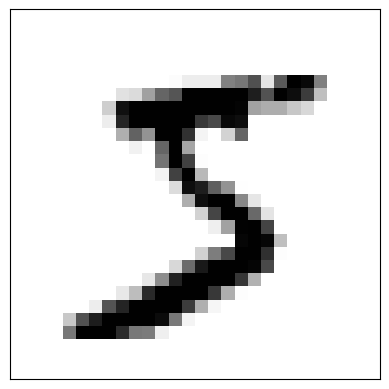

In [25]:
plt.figure()

plt.imshow(image.squeeze(), cmap=plt.cm.binary)
plt.xticks([])
plt.yticks([])
plt.grid(False)

# 8. Training Loop

In [40]:
device = 'cuda' if torch.cuda.is_available() else 'cpu'
learning_rate = 0.005
EPOCHS = 5
BATCH_SIZE = 64
patch_size = 7  # Check Dataset section
num_classes = len(train_dataset.targets.unique()) # Check Dataset section
channels = 1 # Black-White img

model_params = {
    "img_size": img_size,
    "patch_size": patch_size,
    "in_channels": channels,
    "num_classes": num_classes,
    "embed_dim": 64,
    "depth": 6,
    "num_attn_heads": 4,
    "mlp_ratio": 4,
    "dropout_p": 0.05,
}

training_params = {
    "learning_rate": learning_rate,
    "epochs": EPOCHS,
    "batch_size": BATCH_SIZE,
    "device": device
}

params = {**model_params, **training_params}

In [34]:
vit_model = VisionTransformer(
    **model_params
)

In [35]:
# 1x28x28 -> 1 channel, 28x28 img res; 1x1x28x28 -> batch 1, 1 channel, 28x28 img res
image.shape, image.unsqueeze(0).shape

(torch.Size([1, 28, 28]), torch.Size([1, 1, 28, 28]))

In [36]:
vit_model.forward(image.unsqueeze(0))

tensor([[0.0401, 0.0806, 0.3207, 0.0644, 0.1004, 0.0350, 0.1143, 0.0707, 0.1251,
         0.0487]], grad_fn=<SoftmaxBackward0>)

In [37]:
total_params = sum(p.numel() for p in vit_model.parameters() if p.requires_grad)
print(f"Total number of parameters: {total_params}")

Total number of parameters: 303882


In [38]:
vit_model.to(device)

criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(vit_model.parameters(),
                       lr=training_params.get("learning_rate"))

In [39]:
def train(
        model: nn.Module,
        dataloader: DataLoader,
        criterion: nn.CrossEntropyLoss,
        optimizer: optim.Optimizer,
        epochs: int,
        device: str):
    model.train()

    for epoch in range(epochs):
        total_loss = 0
        corrected_pred = 0
        total_pred = 0

        for images, labels in dataloader:
            images, labels = images.to(device), labels.to(device)

            outputs = model(images)

            optimizer.zero_grad()
            loss = criterion(outputs, labels)

            loss.backward()
            optimizer.step()

            total_loss += loss.item()*images.size(0)

            predicted = torch.argmax(outputs, dim=1)
            corrected_pred += (predicted == labels).sum().item()
            total_pred += labels.size(0)

        total_epoch_loss = total_loss / total_pred
        epoch_accuracy = corrected_pred / total_pred
        print(
            f"Epoch {epoch + 1}, Loss: {total_epoch_loss}, Accuracy: {epoch_accuracy: .4f}")

In [41]:
def evaluate(
    model: nn.Module,
    dataloader: DataLoader,
    criterion: nn.CrossEntropyLoss,
    device: str,
):
    model.eval()
    total_loss = 0
    correct_pred = 0
    total_pred = 0

    with torch.no_grad():
        for images, labels in dataloader:
            images, labels = images.to(device), labels.to(device)

            outputs = model(images)
            loss = criterion(outputs, labels)

            total_loss += loss.item() * images.size(0)
            predicted = torch.argmax(outputs, dim=1)
            correct_pred += (predicted == labels).sum().item()
            total_pred += labels.size(0)

    test_loss = total_loss / total_pred
    test_acc = correct_pred / total_pred
    return test_loss, test_acc

In [ ]:
with mlflow.start_run():
    mlflow.log_params(params)
    train(
        model=vit_model,
        dataloader=train_loader,
        criterion=criterion,
        optimizer=optimizer,
        epochs=training_params.get("epochs"),
        device=training_params.get("device")
    )

    test_loss, test_acc = evaluate(
        model=vit_model,
        dataloader=test_loader,
        criterion=criterion,
        device=training_params.get("device")
    )

    mlflow.log_metrics({"test_accuracy": test_acc, "test_loss": test_loss})
    mlflow.pytorch.log_model(pytorch_model=vit_model, name="vit_model", input_example=image.unsqueeze(0).numpy(), export_model=True)

Epoch 1, Loss: 1.8270789755503336, Accuracy:  0.6343
Epoch 2, Loss: 1.7311853004455566, Accuracy:  0.7294
Epoch 3, Loss: 1.7395221652984618, Accuracy:  0.7213
Epoch 4, Loss: 1.7916810525258382, Accuracy:  0.6685
Epoch 5, Loss: 1.7696673566182455, Accuracy:  0.6908


2026/03/01 12:02:06 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/03/01 12:02:07 WARNING mlflow.models.signature: Failed to infer the model signature from the input example. Reason: RuntimeError('Input type (torch.FloatTensor) and weight type (torch.cuda.FloatTensor) should be the same or input should be a MKLDNN tensor and weight is a dense tensor'). To see the full traceback, set the logging level to DEBUG via `logging.getLogger("mlflow").setLevel(logging.DEBUG)`.
2026/03/01 12:02:07 WARNING mlflow.pytorch: Saving pytorch model by Pickle or CloudPickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization.The recommended safe alternative is to set 'export_model' to True to save the pytorch model using the safe graph model format.
2026/03/01 12:02:13 WARNING mlflow.utils.environment: Failed to resolve installed pip version. ``pip`` w

🏃 View run upset-bear-755 at: http://localhost:5000/#/experiments/1/runs/134d0467a4254498836b3522870ee986
🧪 View experiment at: http://localhost:5000/#/experiments/1


In [ ]:
vit_model.forward(image.to(device).unsqueeze(0))

In [ ]:
torch.argmax(vit_model.forward(image.to(device).unsqueeze(0))).item()